# Makemore: part 3

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [18]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append
  
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])         # 80%
Xdev, Ydev = build_dataset(words[n1:n2])     # 10%
Xte, Yte = build_dataset(words[n2:])         # 10%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


tensor(-0.0038) tensor(1.0099)
tensor(0.0014) tensor(0.9858)


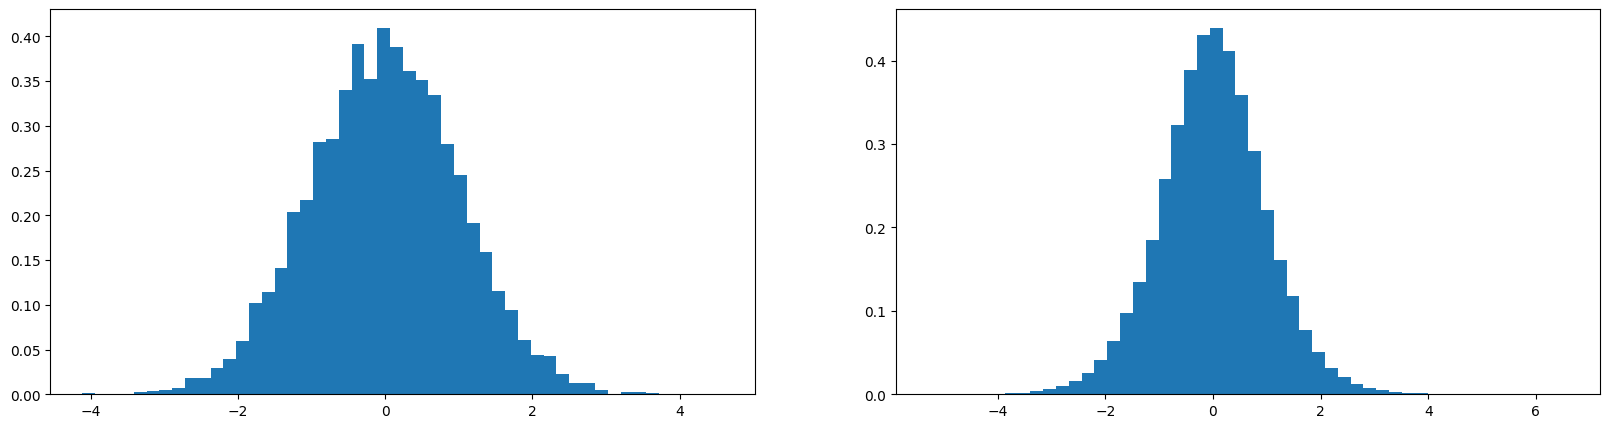

In [76]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 # multiplying w with sqrt of no. of inputs to keep the standard deviation equal
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

## Kaiming initialization can do this for us. showing in et.al Kaiming 2015
## torch.nn.init can do this for us

# https://docs.pytorch.org/docs/2.13/nn.init.html
# gain in our case for tanh is 5/3

In [88]:
# MLP
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = C = torch.randn((vocab_size, n_embd),         generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # Kaiming init for tanh
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # batch normalizatin substraction bias anyway, zero gradient always
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 00.1
b2 = torch.randn(vocab_size,                      generator=g) * 0 # make sure b2 is initialized 0 so we get logits close to 0 and get rid of the initial part of the hockey stick graph

# batch normalization gain et.al. Ioffe 2015
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [85]:
# Optimizations
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
  
  # Forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation # et.al. Ioffe 2015. We can just normalize these states to be unit guassian at initialization
  # BatchNorm Layer
  # ----------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # ------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # Update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())



      0/ 200000: 3.7445
  10000/ 200000: 2.3038
  20000/ 200000: 2.0136
  30000/ 200000: 2.3882
  40000/ 200000: 2.5823
  50000/ 200000: 2.2400
  60000/ 200000: 2.3476
  70000/ 200000: 1.9091
  80000/ 200000: 2.1240
  90000/ 200000: 2.1451
 100000/ 200000: 2.2609
 110000/ 200000: 1.8966
 120000/ 200000: 2.2864
 130000/ 200000: 2.3060
 140000/ 200000: 2.0761
 150000/ 200000: 2.3997
 160000/ 200000: 2.0905
 170000/ 200000: 2.1693
 180000/ 200000: 2.2052
 190000/ 200000: 1.8057


In [66]:
# plt.hist(h.view(-1).tolist(), 50);

# plt.hist(hpreact.view(-1).tolist(), 50);

# plt.figure(figsize=(20, 10))
# plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [67]:
# loss we would expect on the frist run because we should ideally start with a uniform probability so about 1/27.0
# -torch.tensor(1/27.0).log()

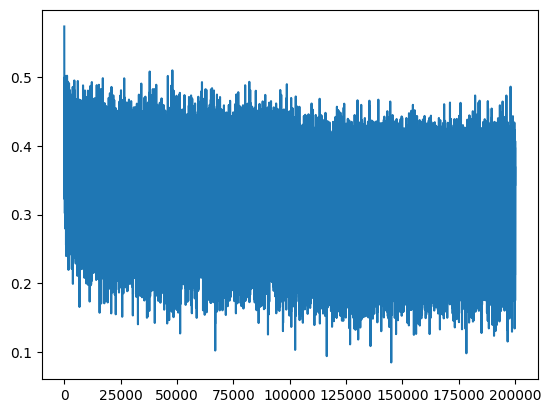

In [68]:
plt.plot(lossi)

In [86]:
@torch.no_grad() # this is decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0704219341278076
val 2.114466428756714


In [62]:
# Sampling from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    # forward pass the neural net
    emb = C[torch.tensor([context])] # 1, block_size_d
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    # sample from the distribution
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)
    # if we sample the special '.' token, break
    if ix == 0:
      break

  print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
ambrilli.
kimri.
reh.
cassanden.
jazonta.
delynn.
jareeicolliana.
chaily.
kaleigh.
ham.
port.
quint.
sulie.
alianni.
wate.
madiaryxie.
kael.
dru.
brey.


In [89]:
## Making a deeper network

class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
      self.eps = eps
      self.momentum = momentum
      self.training = True
      # parameters (trained with backprop)
      self.gamma = torch.ones(dim)
      self.beta = torch.zeros(dim)
      #buffers (trained with a running 'momentum update')
      self.running_mean = torch.zeros(dim)
      self.running_var = torch.ones(dim)

    def __call__(self, x):
      # calculate the forward pass
      if self.training:
        xmean = x.mean(0, keepdim=True) # batch mean
        xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
      else:
        xmean = self.running_mean
        xvar = self.running_var
      xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
      self.out = self.gamma * xhat + self.beta
      # update the buffers
      if self.training:
        with torch.no_grad():
          self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
          self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
      return self.out

    def parameters(self):
      return [self.gamma, self.beta]


class Tanh:

  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


      